In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_card_customers.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.count()

,0
CUST_ID,8950
BALANCE,8950
BALANCE_FREQUENCY,8950
PURCHASES,8950
ONEOFF_PURCHASES,8950
INSTALLMENTS_PURCHASES,8950
CASH_ADVANCE,8950
PURCHASES_FREQUENCY,8950
ONEOFF_PURCHASES_FREQUENCY,8950
PURCHASES_INSTALLMENTS_FREQUENCY,8950


In [ ]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
replace_data_credit= round(df['CREDIT_LIMIT'].median(), 1)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(replace_data_credit)

In [ ]:
replace_data_min_payments = round(df['MINIMUM_PAYMENTS'].median(), 1)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(replace_data_min_payments)

In [ ]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


----

Applichiamo la transformazione logaritmica sulle variabili

In [ ]:
df = df.drop(columns=['CUST_ID'])

log_columns = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PURCHASES_TRX',
    'CASH_ADVANCE_TRX'
]

for col in log_columns:
    df[col] = np.log1p(df[col])

Ora standardizziamo tutto il dataset

In [ ]:
ss = StandardScaler()
df_ss = ss.fit_transform(df)
df_ss = pd.DataFrame(df_ss, columns=df.columns)

display(df_ss.head())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.810069,-0.579510,-1.447163,-0.824484,-0.829837,-0.525551,0.36068
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.784603,-1.379210,0.926060,1.065033,0.908188,0.234227,0.36068
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.810069,0.487865,1.010229,-0.119300,0.450411,-0.525551,0.36068
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.123281,-0.874655,1.010229,-4.161996,-0.144387,-0.525551,0.36068
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.810069,-0.874655,-1.224909,-0.064979,-0.351828,-0.525551,0.36068


---

Calcoliamo l'inerzia per poter poi effettuare il cluster col numero più adatto di K

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_ss)
    wcss.append(kmeans.inertia_)

print("WCSS values from 1 to 10:", wcss)

WCSS values from 1 to 10: [152149.9999999995, 113331.60365166288, 95644.63060473705, 86546.9597491297, 77933.0252399021, 71656.32514199057, 67972.56254952193, 64555.44725581647, 61499.829596377975, 58828.17381790074]


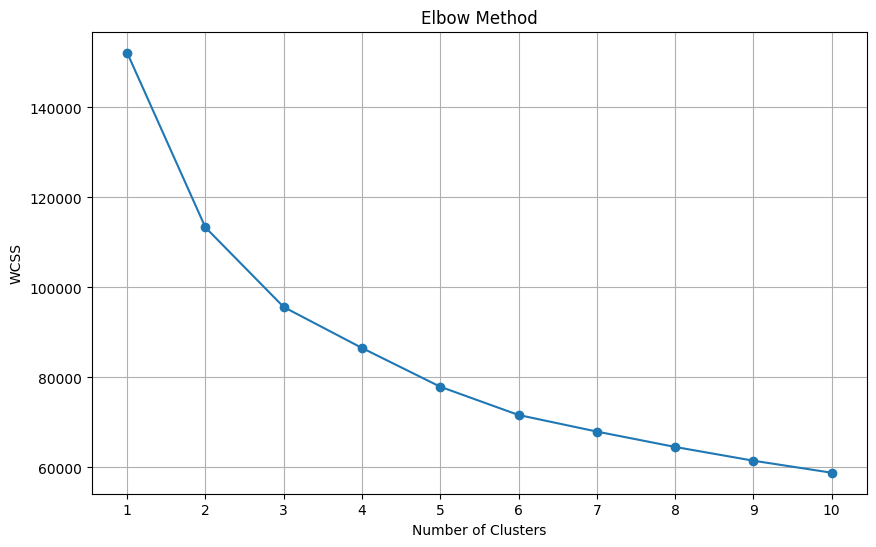

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In base al grafico dell'elboe method, iln numero di cluster da utilizzare sembrerebbe 3, ma per sicurezza testiamo anche con il silhouette score

K = 2: Silhouette Score = 0.2684
K = 3: Silhouette Score = 0.2439
K = 4: Silhouette Score = 0.2273
K = 5: Silhouette Score = 0.2285
K = 6: Silhouette Score = 0.2213
K = 7: Silhouette Score = 0.2065
K = 8: Silhouette Score = 0.1841
K = 9: Silhouette Score = 0.1786
K = 10: Silhouette Score = 0.1851


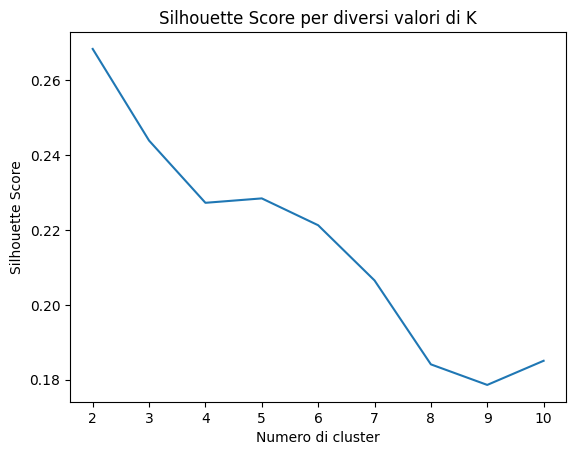

In [33]:
silhouette_scores = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(df_ss)
    score = silhouette_score(df_ss, labels)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.4f}")

#grafico
plt.figure()
plt.plot(k_range, silhouette_scores)
plt.xlabel("Numero di cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per diversi valori di K")
plt.show()


Senza dubbio K=2 sarebbe il numero migliore di cluster a livello strettamente matematico, ma se pensiamo a una segmentazione più utile a livello di strategia di marketing. Per questo motivo si conferma l'utilizzo di 3 cluster.

In [34]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_ss)

df_ss['Cluster'].value_counts()

,count
Cluster,
0,3174
1,2899
2,2877


In [38]:
df['Cluster'] = df_ss['Cluster']
cluster_analysis = df.groupby('Cluster').mean()
cluster_analysis

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,7.026096,0.981291,7.271932,5.815895,5.431747,2.747943,0.838954,0.458065,0.613086,0.105041,0.668526,3.200468,8.387904,7.375902,6.335427,0.160418,11.789855
1,4.095961,0.720537,5.528575,2.204768,3.963989,0.408083,0.523996,0.079891,0.428293,0.009306,0.067966,1.923257,7.808752,5.748543,5.015705,0.266742,11.384615
2,7.289411,0.920445,1.648727,1.330199,0.442142,6.882453,0.071857,0.043967,0.025776,0.295156,1.737337,0.425454,8.059750,6.678309,6.360683,0.032428,11.350365


In base ai dati ottenuti, potremmo definire i 3 cluster ottenuti con i nomi:

0 = Clienti affidabili

1 = Clienti rateali

2 = Clienti poco attivi

---

GRAFICI

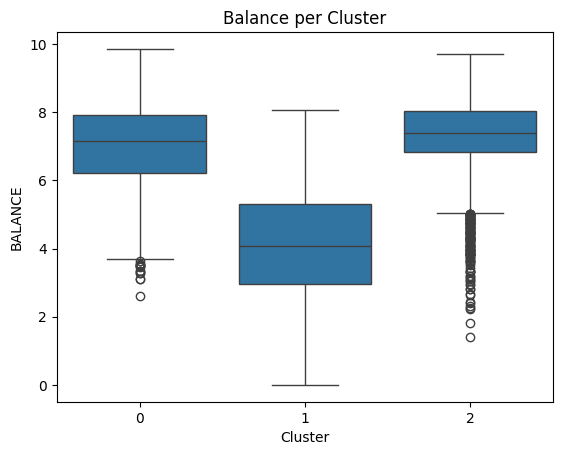

In [44]:
sns.boxplot(x='Cluster', y='BALANCE', data=df)
plt.title("Balance per Cluster")
plt.show()

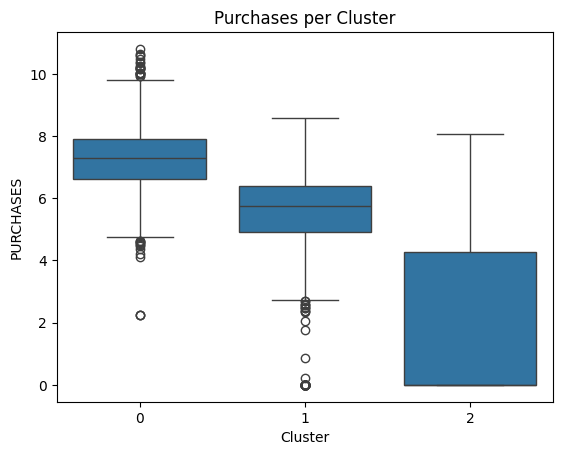

In [47]:
sns.boxplot(x='Cluster', y='PURCHASES', data=df)
plt.title("Purchases per Cluster")
plt.show()

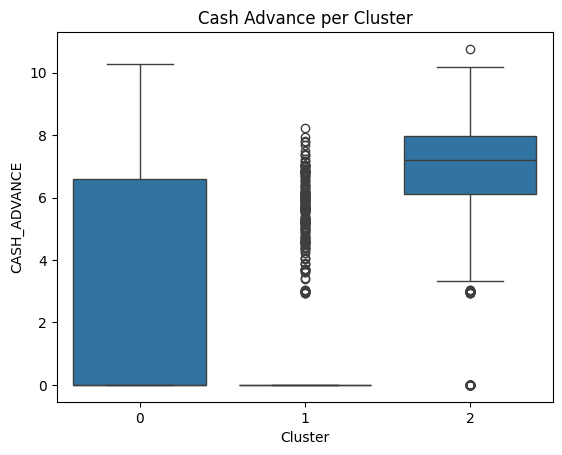

In [48]:
sns.boxplot(x='Cluster', y='CASH_ADVANCE', data=df)
plt.title("Cash Advance per Cluster")
plt.show()

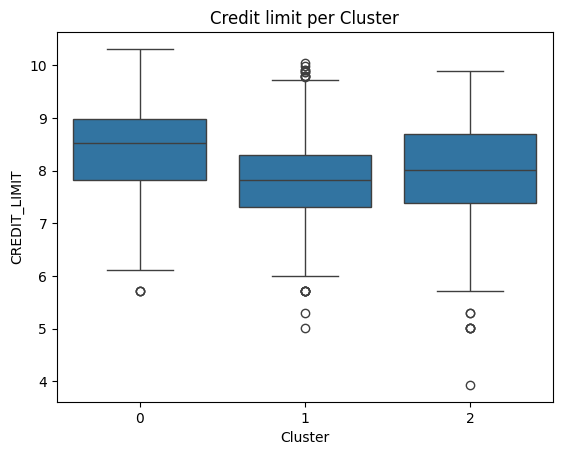

In [49]:
sns.boxplot(x='Cluster', y='CREDIT_LIMIT', data=df)
plt.title("Credit limit per Cluster")
plt.show()

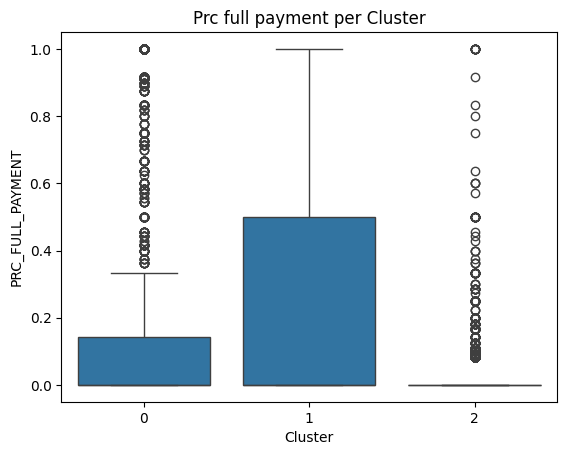

In [50]:
sns.boxplot(x='Cluster', y='PRC_FULL_PAYMENT', data=df)
plt.title("Prc full payment per Cluster")
plt.show()

---
STRATEGIE DI MARKETING

**Cluster 0**

I clienti di questo gruppo hanno saldo, numero di acquisti e il limite di credito alti ed effettuano pagamenti puntuali. Per fidelizzarli ulteriormente, conviene proporre programmi premium, iniziative di loyalty e valutare un aumento del loro limite di credito.

Dati numerici:

BALANCE: ~7,03

PURHCASES: ~7,27

CREDIT_LIMIT: ~8,39

PRC_FULL_PAYMENT: ~0,16

**Cluster 1**

Questi clienti fanno molti acquisti rateali, quindi hanno frequenti pagamenti anche se di importo ridotto. Data la loro preferenza per gli acquisti rateali, l'attenzione del marketing dovrebbe essere rivolta a incentivare un ulteriore utilizzo del pagamento rateale, sarebbe quindi strategico offrire finanziamenti dedicati e agevolare i tassi, così da rendere più semplice e conveniente continuare a usare i servizi.

Dati numerici:

BALANCE: ~4.10

INSTALLMENTS_PURCHASES: ~3.96

CASH_ADVANCE: ~0.41 (molto basso)

PRC_FULL_PAYMENT: ~0.27 (il più alto tra i 3)

**Cluster 2**

I clienti di questo gruppo hanno poche transazioni e bassa frequenza di acquisti, anche se presentano un saldo elevato. Full_payments è molto basso, il che indica che raramente saldano l'intero saldo.Per stimolarne l’attività, si possono proporre incentivi come cashback temporanei, promozioni sull’uso della carta e campagne mirate di riattivazione.

Dati numerici:

BALANCE: ~7.29 (il più alto tra i 3)

PURCHASES: ~1.65 (molto basso)

CASH_ADVANCE: ~6.88 (il più alto tra i 3)

PRC_FULL_PAYMENT: ~0.03 (il più basso tra i 3)

---

CONCLUSIONE

Possiamo dire che la segmentazione dei clienti in questi tre gruppi distinti può dare all'azienda un approccio di marketing più personalizzato, invece che univoco. In questo modo i cluster possono essere affrontati con strategie personalizzate portando a un coinvolgimento e fidelizzazione dei clienti più efficaci.